# 08. Final Evaluation & Publication Figures

This notebook conducts the final comprehensive three-way evaluation comparing Standard MLP, Original SCARF, and TTL-Aware SCARF under dTTL perturbations, and produces publication-ready multi-panel comparative figures and summary tables.



MLP vs ORIGINAL SCARF vs TTL-AWARE SCARF — dTTL COMPARISON
       Model  dTTL_%    TPR  AUROC  AUPRC  TPR_degradation
    Original     -15 0.6932 0.8901 0.9162           0.0532
Standard MLP     -15 0.3837 0.6460 0.7334           0.0379
   TTL-aware     -15 0.7098 0.8874 0.9131           0.0348
    Original     -10 0.7110 0.8911 0.9165           0.0354
Standard MLP     -10 0.3949 0.6510 0.7377           0.0268
   TTL-aware     -10 0.7217 0.8881 0.9133           0.0229
    Original      -5 0.7285 0.8919 0.9167           0.0180
Standard MLP      -5 0.4072 0.6554 0.7419           0.0145
   TTL-aware      -5 0.7329 0.8886 0.9134           0.0117
    Original      -2 0.7396 0.8923 0.9168           0.0068
Standard MLP      -2 0.4160 0.6590 0.7452           0.0057
   TTL-aware      -2 0.7404 0.8888 0.9134           0.0042
    Original       0 0.7464 0.8923 0.9166           0.0000
Standard MLP       0 0.4217 0.6606 0.7469           0.0000
   TTL-aware       0 0.7446 0.8887 0.9132           0.0

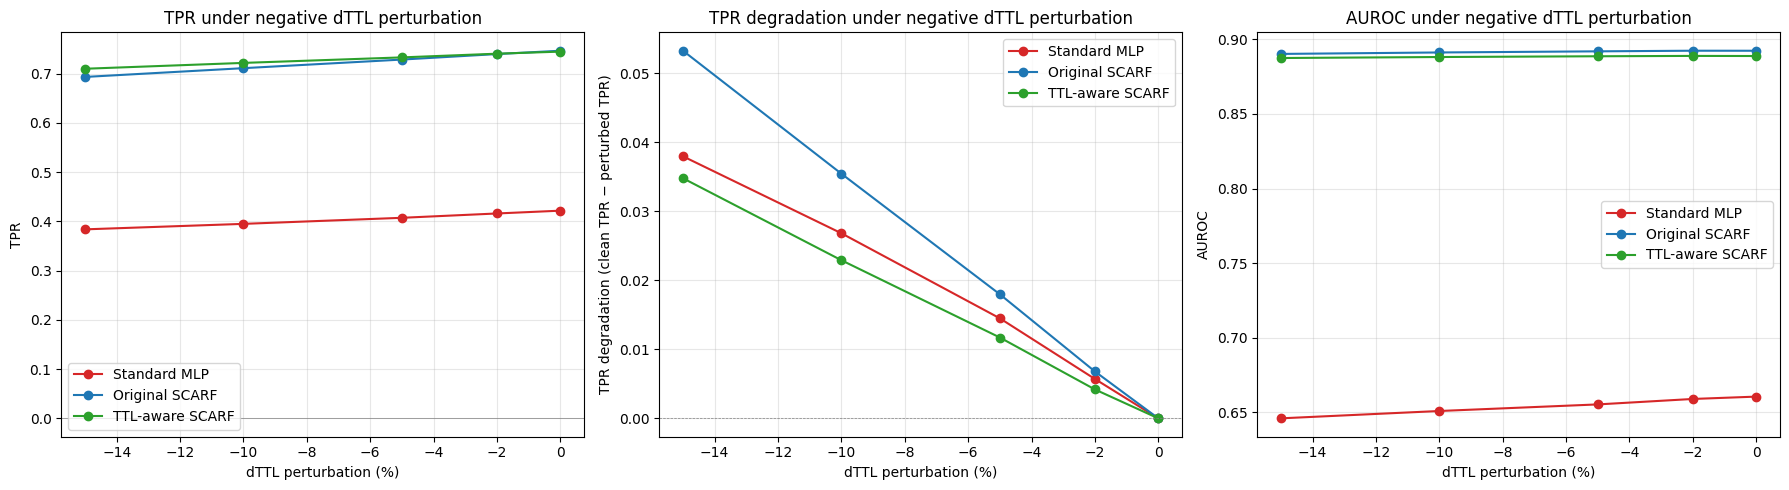


Saved:
FINAL_mlp_dttl_results.csv
FINAL_three_way_comparison.csv
FINAL_mlp_vs_scarf_comparison.png


In [44]:
# =============================================================================
# APPEND THIS AFTER FINAL_scarf_comparison.py (needs final_df from that script,
# plus the standard MLP model + its evaluate function from the baseline cells)
# =============================================================================

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix

DTTL_LEVELS = [-2, -5, -10, -15]

# -----------------------------------------------------------------------
# 1. MLP EVALUATION HELPER — matches your frozen baseline (cell 26):
#    mlp_models is a dict {42: model, 123: model, 2026: model}, and
#    `device` is the single global torch.device from that cell.
# -----------------------------------------------------------------------

def evaluate_mlp(model, X, y, device):
    model.eval()
    X_t = torch.tensor(np.asarray(X, dtype=np.float32), device=device)
    y_np = np.asarray(y).reshape(-1).astype(int)
    with torch.no_grad():
        logits = model(X_t).reshape(-1)
        probs = torch.sigmoid(logits).cpu().numpy()
    preds = (probs >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_np, preds, labels=[0, 1]).ravel()
    tpr = tp / (tp + fn) if (tp + fn) else 0.0
    auc = roc_auc_score(y_np, probs)
    ap = average_precision_score(y_np, probs)
    return tpr, auc, ap


# -----------------------------------------------------------------------
# 2. BUILD MLP ROWS, per-seed, same 3 seeds as SCARF, using the SAME
#    dttl_test_sets so the comparison is apples-to-apples.
# -----------------------------------------------------------------------
# Requires mlp_models (dict keyed by seed) and device from cell 26.

assert "mlp_models" in globals(), "Run cell 26 first (freezes mlp_models)."

mlp_rows = []
for seed in [42, 123, 2026]:
    model = mlp_models[seed]
    seed_device = next(model.parameters()).device  # robust even if `device` changed later

    clean = evaluate_mlp(model, X_test_s, y_test_s, seed_device)
    mlp_rows.append({"Seed": seed, "Model": "Standard MLP", "dTTL_%": 0,
                      "TPR": clean[0], "AUROC": clean[1], "AUPRC": clean[2],
                      "TPR_degradation": 0.0})

    for level in DTTL_LEVELS:
        m = evaluate_mlp(model, dttl_test_sets[level], y_test_s, seed_device)
        mlp_rows.append({"Seed": seed, "Model": "Standard MLP", "dTTL_%": level,
                          "TPR": m[0], "AUROC": m[1], "AUPRC": m[2],
                          "TPR_degradation": clean[0] - m[0]})

mlp_df_raw = pd.DataFrame(mlp_rows)
mlp_df_raw.to_csv("FINAL_mlp_dttl_results_by_seed.csv", index=False)

# Average over seeds to match the SCARF summary format
mlp_df = (mlp_df_raw.groupby(["Model", "dTTL_%"])[["TPR", "AUROC", "AUPRC", "TPR_degradation"]]
          .mean().reset_index())
mlp_df.to_csv("FINAL_mlp_dttl_results.csv", index=False)

# -----------------------------------------------------------------------
# 3. COMBINE MLP + SCARF (Original + TTL-aware) INTO ONE TABLE
# -----------------------------------------------------------------------
# final_df comes from FINAL_scarf_comparison.py (has Seed-level rows for
# Original / TTL-aware SCARF). Average over seeds first for a clean 3-way
# comparison table.

scarf_summary = (
    final_df.groupby(["Model", "dTTL_%"])[["TPR", "AUROC", "AUPRC", "TPR_degradation"]]
    .mean()
    .reset_index()
)

three_way = pd.concat([scarf_summary, mlp_df], ignore_index=True)
three_way = three_way.sort_values(["dTTL_%", "Model"])
three_way.to_csv("FINAL_three_way_comparison.csv", index=False)

print("\n" + "=" * 90)
print("MLP vs ORIGINAL SCARF vs TTL-AWARE SCARF — dTTL COMPARISON")
print("=" * 90)
print(three_way.round(4).to_string(index=False))


# =============================================================================
# 4. VISUALIZATION
# =============================================================================

colors = {"Standard MLP": "#d62728", "Original": "#1f77b4", "TTL-aware": "#2ca02c"}
labels = {"Standard MLP": "Standard MLP", "Original": "Original SCARF", "TTL-aware": "TTL-aware SCARF"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Panel 1: TPR vs dTTL ---
ax = axes[0]
for model_name in ["Standard MLP", "Original", "TTL-aware"]:
    sub = three_way[three_way["Model"] == model_name].sort_values("dTTL_%")
    ax.plot(sub["dTTL_%"], sub["TPR"], marker="o", label=labels[model_name],
            color=colors[model_name])
ax.set_xlabel("dTTL perturbation (%)")
ax.set_ylabel("TPR")
ax.set_title("TPR under negative dTTL perturbation")
ax.axhline(0, color="gray", linewidth=0.5)
ax.legend()
ax.grid(alpha=0.3)

# --- Panel 2: TPR degradation vs dTTL ---
ax = axes[1]
for model_name in ["Standard MLP", "Original", "TTL-aware"]:
    sub = three_way[three_way["Model"] == model_name].sort_values("dTTL_%")
    ax.plot(sub["dTTL_%"], sub["TPR_degradation"], marker="o", label=labels[model_name],
            color=colors[model_name])
ax.set_xlabel("dTTL perturbation (%)")
ax.set_ylabel("TPR degradation (clean TPR − perturbed TPR)")
ax.set_title("TPR degradation under negative dTTL perturbation")
ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
ax.legend()
ax.grid(alpha=0.3)

# --- Panel 3: AUROC vs dTTL (ranking-quality stability) ---
ax = axes[2]
for model_name in ["Standard MLP", "Original", "TTL-aware"]:
    sub = three_way[three_way["Model"] == model_name].sort_values("dTTL_%")
    ax.plot(sub["dTTL_%"], sub["AUROC"], marker="o", label=labels[model_name],
            color=colors[model_name])
ax.set_xlabel("dTTL perturbation (%)")
ax.set_ylabel("AUROC")
ax.set_title("AUROC under negative dTTL perturbation")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("FINAL_mlp_vs_scarf_comparison.png", dpi=200)
plt.show()

print("\nSaved:")
print("FINAL_mlp_dttl_results.csv")
print("FINAL_three_way_comparison.csv")
print("FINAL_mlp_vs_scarf_comparison.png")